In [7]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import preprocess_data as prep
import matplotlib.pyplot as plt


In [8]:
uf_to_region = {
    11: 'Norte', 12: 'Norte', 13: 'Norte', 14: 'Norte',
    15: 'Norte', 16: 'Norte', 17: 'Norte',

    21: 'Nordeste', 22: 'Nordeste', 23: 'Nordeste',
    24: 'Nordeste', 25: 'Nordeste', 26: 'Nordeste',
    27: 'Nordeste', 28: 'Nordeste', 29: 'Nordeste',

    31: 'Sudeste', 32: 'Sudeste', 33: 'Sudeste',
    35: 'Sudeste',

    41: 'Sul', 42: 'Sul', 43: 'Sul',

    50: 'Centro-Oeste', 51: 'Centro-Oeste',
    52: 'Centro-Oeste', 53: 'Centro-Oeste'
}

In [9]:
df = prep.load_cases_data(filename = './data/chikungunya.csv.gz')

df = df.groupby(['date', 'regional_geocode'])[['casos']].sum().reset_index()

df['year'] = df.date.dt.year
df['month'] = df.date.dt.month

df.head()

,date,regional_geocode,casos,year,month
0,2013-12-29,11001,0,2013,12
1,2013-12-29,11002,0,2013,12
2,2013-12-29,11003,0,2013,12
3,2013-12-29,11004,0,2013,12
4,2013-12-29,11005,0,2013,12


In [10]:
df_2 = df.loc[df.month >= 7].groupby(['regional_geocode', 'year'])[['casos']].sum().reset_index()

df_2['region'] = (
    df['regional_geocode']
    .astype(str)
    .str[:2]
    .astype(int)
    .map(uf_to_region)
)

df_2.head()

,regional_geocode,year,casos,region
0,11001,2013,0,Norte
1,11001,2014,0,Norte
2,11001,2015,0,Norte
3,11001,2016,3,Norte
4,11001,2017,5,Norte


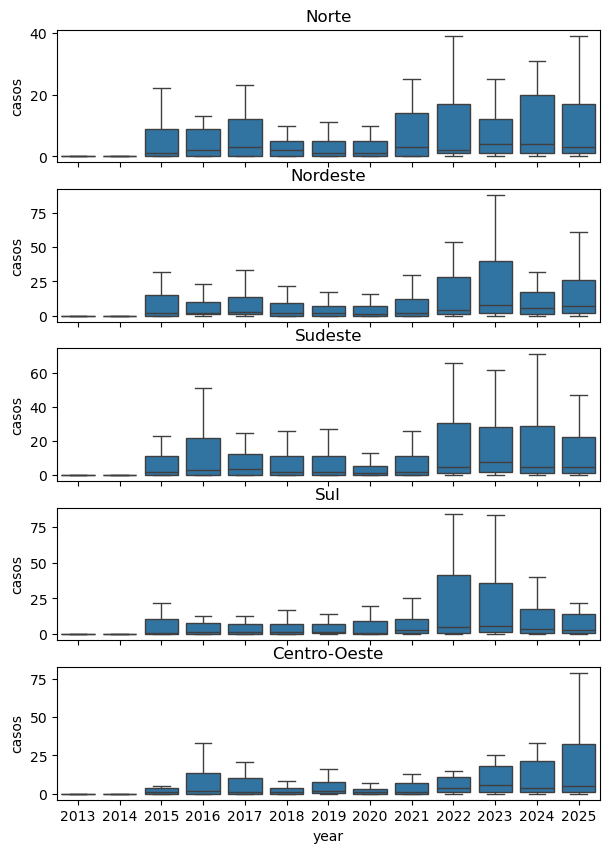

In [11]:
fig, axs = plt.subplots(5,1, figsize = (7, 10), sharex = True)

for reg, ax in zip(df_2.region.unique(), axs.ravel()):

    sns.boxplot(ax=ax, data = df_2.loc[df_2.region == reg], x= 'year', y = 'casos', showfliers = False)

    ax.set_title(reg)

plt.show()

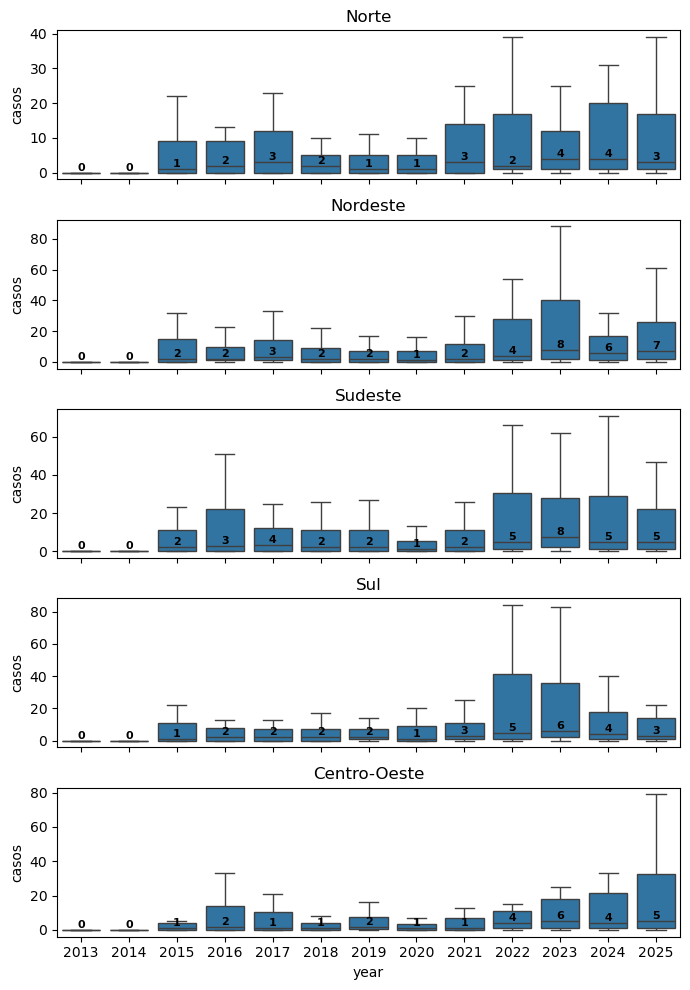

In [12]:
fig, axs = plt.subplots(5, 1, figsize=(7, 10), sharex=True)

for reg, ax in zip(df_2.region.unique(), axs.ravel()):

    df_reg = df_2[df_2.region == reg]

    sns.boxplot(
        ax=ax,
        data=df_reg,
        x='year',
        y='casos',
        showfliers=False
    )

    # mediana por ano
    medians = df_reg.groupby('year')['casos'].median()

    # adiciona texto acima da linha da mediana
    for i, (year, median) in enumerate(medians.items()):
        ax.text(
            i,                  # posição da caixa
            median,             # altura da mediana
            f'{median:.0f}',    # texto
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )

    ax.set_title(reg)

plt.tight_layout()
plt.show()

In [13]:
df_2.shape

(5707, 4)

In [16]:
df_2.loc[df_2.casos >= 10].shape[0]/df_2.shape[0]

0.25652707201682146

In [17]:
df_2.loc[df_2.casos >= 10][['year', 'region']].value_counts()

year  region      
2023  Sudeste         79
2022  Sudeste         68
2024  Sudeste         66
2025  Sudeste         65
2023  Nordeste        53
2017  Sudeste         51
2016  Sudeste         50
2024  Nordeste        47
2015  Sudeste         46
2021  Sudeste         45
2019  Sudeste         44
2022  Nordeste        43
2025  Nordeste        43
2018  Sudeste         43
2017  Nordeste        36
2020  Sudeste         36
2015  Nordeste        35
2016  Nordeste        31
2021  Nordeste        30
2023  Sul             30
2022  Sul             29
2018  Nordeste        28
2020  Nordeste        25
2024  Sul             22
2025  Sul             22
2019  Nordeste        20
2021  Sul             20
2015  Sul             19
2025  Centro-Oeste    17
2024  Norte           16
2020  Sul             16
2019  Sul             15
2023  Centro-Oeste    15
2024  Centro-Oeste    15
2025  Norte           14
2021  Norte           14
2016  Sul             14
2017  Sul             14
2022  Centro-Oeste    14
2017  